<a href="https://colab.research.google.com/github/tphlabs/data/blob/main/Lab2_C/2026.03/Lab2_Capacitor_LogBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# lab2 capacitor

Evgeny Kolonsky march 2026


In [23]:
import numpy as np # math functions
import matplotlib.pyplot as plt # for plotting figures and setting their properties
from scipy.integrate import cumulative_trapezoid as cumtrapz #  numerical integration, scipy<1.6
# from scipy.integrate import cumulative_trapezoid # numerical integration, scipy>=1.6
from scipy.stats import linregress # linear regression
import scipy.constants
from scipy.optimize import curve_fit

In [9]:
# round by meaningful digits
# with respect to error
def round_meaningful(value, error):
  if error <=0:
    # return unchanged and break
    return value, error

  # Power of error
  power_err = int(np.floor(np.log10(error)))

  # Digits of error in format a.bcd
  n_err = error / (10**np.floor(power_err))

  # keep 2-digits only for errors like 1.0, 1.1
  # otherwise round it up
  if n_err >= 1.2:
    n_err = np.ceil(n_err)
    error = n_err * 10** power_err

  error_rounded = np.round(error, -power_err)
  value_rounded = np.round(value, -power_err)

  return value_rounded, error_rounded

def sum_err(err1, err2):
  return np.sqrt(err1**2 + err2**2)

# Format C value with respect to uncertainty and some text
def niceC(value, error=0, label=''):

  value, error = round_meaningful(value, error)

  return f'Capacitance by {label}: {value*1e12:.0f} ± {error*1e12:.0f} pF'

def printC(value, error=0, label=''):
  print(niceC(value, error, label))



<div dir=rtl>
תזכורת:
$$ C = {A \varepsilon_0 \varepsilon_r \over d}$$

In [45]:
# Resistors:
R1 = 75.3e3 # kOhm,
R1_err = R1 *0.5e-2 +0.1e3 # Accuracy to 2MΩ rgs: ±(0.5% rdg +1dgt)
R2 = 1197 # ohm,
R2_err = R2 *0.5e-2 + 1 # Accuracy to 2MΩ rgs: ±(0.5% rdg +1dgt)
# inner resistance of the inpulse generator (do not trust, measure it)
r_in = 0 # ohm
r_in_err = 0

# Disks:
# height of three spacers, mm, with resolutuon 0.01 mm
d1 = 0.58e-3
d2 = 0.60e-3
d3 = 0.60e-3
# error
d123_err = 0.02e-3 # mm
# average space between disks:
d = (d1 + d2 + d3) /3
d_err = np.sqrt(3) * d123_err
d_error_relative =  d_err / d

# Disk surface square
diameter = 260e-3 # mm +- 1mm
diameter_err = 1e-3 #mm
A = np.pi * diameter**2 / 4
A_error_relative  = 2* diameter_err / diameter
C_error_relative = d_error_relative  +  A_error_relative

# Constants
eps0 = scipy.constants.epsilon_0
epsr = 1 # for air between plates

C = A * eps0 * epsr / d
C_err = C * C_error_relative
printC(C, C_err, 'Geometry')

Capacitance by Geometry: 790 ± 60 pF


<div dir=rtl>
<h3>
   מדידות מקדימות:
</h3>

<div dir=rtl>
<h3>
    קיבול לפי מד הLCR
</h3>


<div class="alert alert-block alert-success", dir=rtl>
<b>רגע של מחשבה:</b> איך כדאי למקם חוטי המדידה בכדי למזער את השפעתם על מדידת קיבול הקבל?
</div>

In [5]:
# direct measurement
C_lcr = 725e-12
C_lcr_err = C_lcr *0.01 + 3e-12 #±(1.0% rdg +3dgt)

printC(C_lcr, C_lcr_err, 'LCR')

Capacitance by LCR: 720 ± 10 pF


<div dir=rtl>
<h3>
    קיבול לפי $Q=CV$
</h3>

<div class="alert alert-block alert-success", dir=rtl>
<b>רגע של מחשבה:</b> מה משתנה כתלות בערכו של R1?
</div>

<div dir=rtl>
טעינת הנתונים מקובץ:

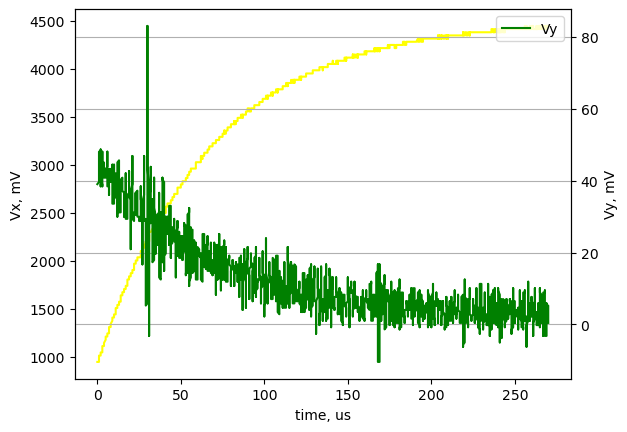

In [46]:
url = 'd:/'
filename = url+'260_75.csv'
t, vx, vy = np.loadtxt(filename, delimiter=',', skiprows=1, usecols=[0,1,2]).T
t -= np.min(t)
plt.plot(t*1e6, vx*1e3, color='yellow', label='Vx')
plt.gca().set_ylabel('Vx, mV')
plt.gca().set_xlabel('time, us')
ax2 = plt.twinx()
ax2.plot(t*1e6, vy*1e3, color='green', label='Vy')
ax2.set_ylabel('Vy, mV')
plt.legend()
plt.grid()

<div dir=rtl>
חישוב המתח על הקבל והזרם במעגל:

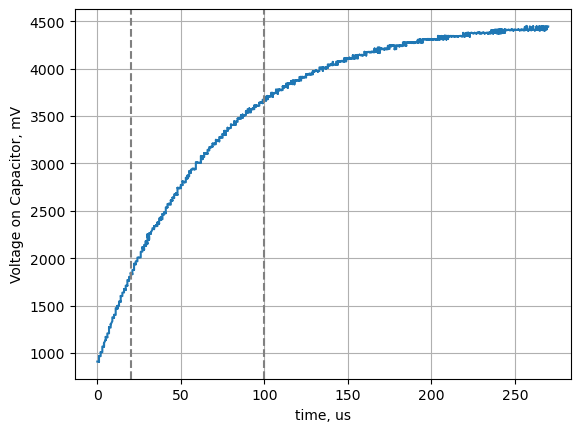

In [47]:
# time to cut exponential decay curve
TIME_MAX = 100e-6 #s
TIME_MIN = 20e-6
mask =  (t > TIME_MIN) & (t <  TIME_MAX)

V = vx - vy#
I = vy / R2#
plt.plot(t * 1e6, V*1e3)
plt.plot(t[V<0] * 1e6, V[V<0]*1e3)
plt.gca().set_ylabel('Voltage on Capacitor, mV')
plt.gca().set_xlabel('time, us')
plt.axvline(TIME_MAX*1e6, ls='--', color='gray')
plt.axvline(TIME_MIN*1e6, ls='--', color='gray')
plt.grid()

<div dir=rtl>
אינטרגציה לזרם בשביל לקבל את המטען:

Q-method capacitance: 759 ± 1pF


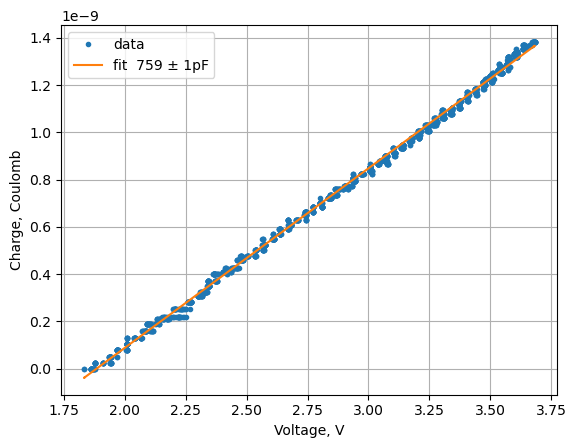

In [48]:
Q = cumtrapz(I[mask], t[mask], initial=0)
fit = linregress(V[mask], Q)
C = fit.slope
C_err = fit.stderr

plt.plot(V[mask], Q, '.', label='data')
plt.plot(V[mask], fit.intercept + fit.slope * V[mask], label=f'fit  {C * 1e12 :.0f} ± {C_err *1e12:.0f}pF')
plt.legend()
plt.grid()
plt.xlabel('Voltage, V')
plt.ylabel('Charge, Coulomb')


print(f"Q-method capacitance: {C * 1e12 :.0f} ± {C_err *1e12:.0f}pF")


<div dir=rtl>
גרף של המטען הצבור בקבל כתלות במתח על הקבל:

<div class="alert alert-block alert-info", dir=rtl>
<b>תזכורת:</b> הקשר בין המטען למתח בקבל הוא Q=CV - קשר ליניארי
</div>

<div dir=rtl>
חישוב הקיבול מתוך הגרף:

<div dir=rtl>
<h3>
   קיבול לפי $\tau = RC$
</h3>

<div dir=rtl>
נשרטט גרף עם רגרסיה ליניארית:

<div dir=rtl>
חישוב הקיבול מתוך הגרף:

Capacitance by tau=RC method: 970 ± 10 pF


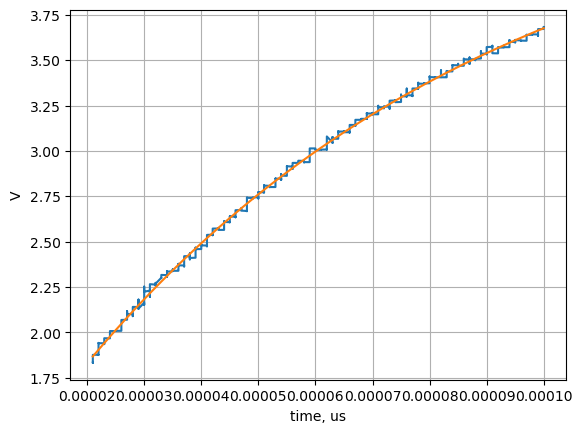

In [49]:
def discharge(t, tau, A, offset):
    return offset + A * np.exp(-t/tau)
    
tmask = t[mask]
p0 = [(R1+R2) * 700e-12, -1, 4]
popt, pcov =  curve_fit(discharge, t[mask], V[mask], p0=p0)
plt.plot(t[mask], V[mask])
tau, A, offset = popt
R = R1 + R2
R_rel = sum_err(R1_err/R1,   R2_err/R2)
C_rel = sum_err(tau_rel, R_rel)
C = tau / R
C_err = C * C_rel
plt.plot(t[mask], discharge(t[mask], tau, A, offset))
plt.grid()
plt.xlabel('time, us')
plt.ylabel('V')
printC(C, C_err, 'tau=RC method')

<div class="alert alert-block alert-warning", dir=rtl>
<b>בדיקה עצמית:</b> האם ארבעת ערכי הקיבול חופפים בטווחי השגיאה שלהם? האם יש ביניהם חריג?
</div>

In [42]:
#discharge(t[mask], tau, A, offset)
popt

array([ 1.99036234e+04, -1.25174961e-01,  3.37359269e+00])

[חזרה לתחילת מהלך הניסוי](#mahalah)

[חזרה לתחילת קבל 1](#cap1)

<div dir=rtl>
<h2>
    בחירת קבל 2 (שטח שונה)
<a id="cap2"></a>
</h2>

<br>
תיעוד בחירה: <br>
.

.

.

# Disk 260 mm, small distance

Capacitance by LCR: 535 ± 9 pF
Capacitance by Geometry: 510 ± 30 pF


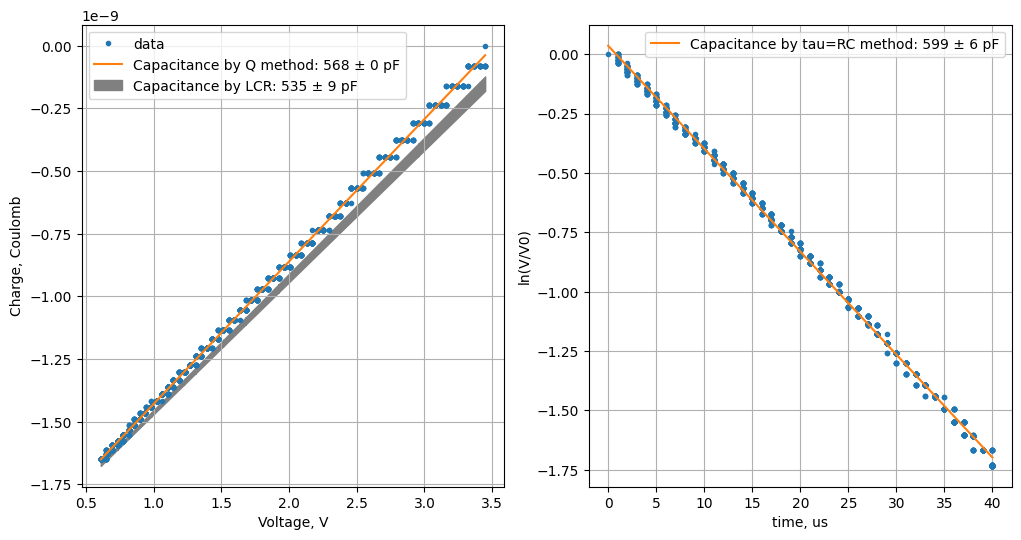

In [9]:
# LCR
C_lcr = 535e-12
C_lcr_err = C_lcr *0.01 + 3e-12 #±(1.0% rdg +3dgt)

printC(C_lcr, C_lcr_err, 'LCR')

# raw data
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
filename = url+'A260_d0_air_1.csv'
t, vx, vy = np.loadtxt(filename, delimiter=',', skiprows=1, usecols=[0,1,2]).T
t -= np.min(t)
V = vx - vy#
I = vy / R2#


# Q
Q = cumtrapz(I[mask], t[mask], initial=0)
fit = linregress(V[mask], Q)
C = fit.slope
C_err = fit.stderr
text = niceC(C, C_err, 'Q method')
ax = axs[0]
ax.plot(V[mask], Q, '.', label='data')
ax.plot(V[mask], fit.intercept + fit.slope * V[mask], label=f'{text}')
lcr_top  = C_lcr + C_lcr_err
lcr_bottom = C_lcr - C_lcr_err
ytop = fit.intercept + lcr_top * V[mask]
ybottom =   fit.intercept + lcr_bottom * V[mask]
ax.fill_between(V[mask], ytop, ybottom, color='gray', label=niceC(C_lcr, C_lcr_err, 'LCR'))
ax.legend()
ax.grid()
ax.set_xlabel('Voltage, V')
ax.set_ylabel('Charge, Coulomb')

# RC
lnv = np.log(V[mask]/V[0])
tmask = t[mask]
ax = axs[1]
ax.plot(tmask*1e6, lnv,'.')
fit = linregress(tmask, lnv)
tau = - 1 / fit.slope
tau_rel = np.abs(fit.stderr / fit.slope)
R = R1 + R2
R_rel = sum_err(R1_err/R1,   R2_err/R2)
C_rel = sum_err(tau_rel, R_rel)
C = tau / R
C_err = C * C_rel
text = niceC(C, C_err, 'tau=RC method')
ax.plot(t[mask]*1e6, fit.intercept + fit.slope * t[mask], label=text)
ax.grid()
ax.set_xlabel('time, us')
ax.set_ylabel('ln(V/V0)')
ax.legend()

# geometry
d1 = 0.90e-3
d2 = 0.95e-3
d3 = 0.90e-3
# error
d123_err = 0.02e-3 # mm
# average space between disks:
d = (d1 + d2 + d3) /3
d_err = np.sqrt(3) * d123_err
d_error_relative =  d_err / d


# Disk surface square
diameter = 260e-3 # mm +- 1mm
diameter_err = 1e-3 #mm
A = np.pi * diameter**2 / 4
A_error_relative  = 2* diameter_err / diameter
C_error_relative = d_error_relative  +  A_error_relative

# Constants
eps0 = scipy.constants.epsilon_0
epsr = 1 # for air between plates

C = A * eps0 * epsr / d
C_err = C * C_error_relative
printC(C, C_err, 'Geometry')





# The same 260 mm disk, more space, air

Capacitance by LCR: 465 ± 8 pF
Capacitance by Geometry: 450 ± 20 pF


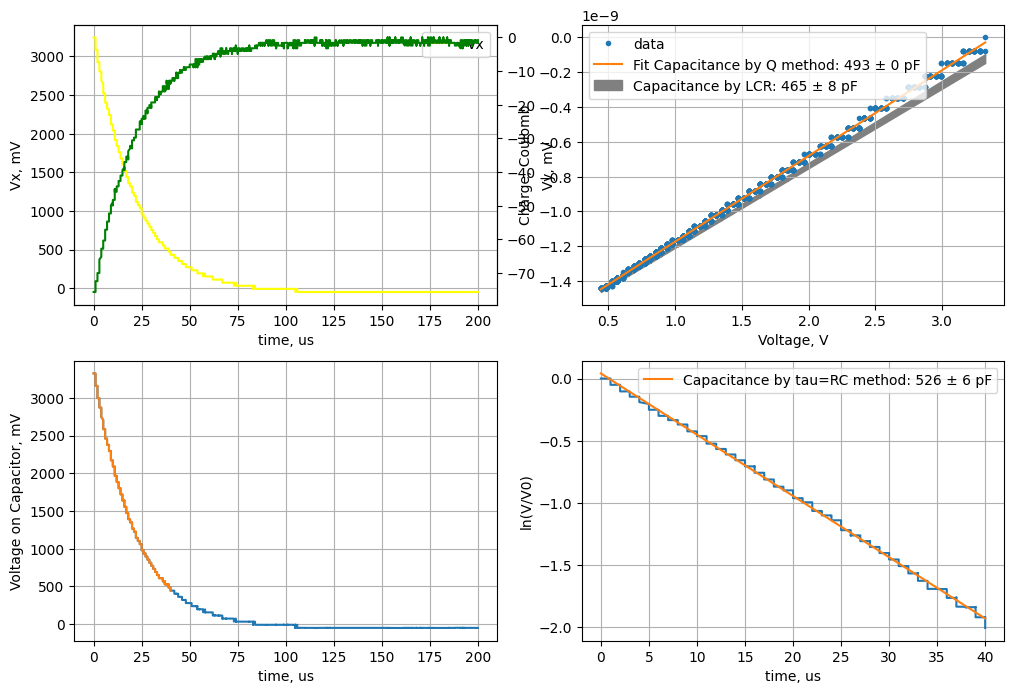

In [10]:
url = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab2_C/2026.03/'

# LCR
C_lcr = 465e-12
C_lcr_err = C_lcr *0.01 + 3e-12 #±(1.0% rdg +3dgt)

printC(C_lcr, C_lcr_err, 'LCR')

# raw data
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
filename = url+'A260_d1_air.csv'
t, vx, vy = np.loadtxt(filename, delimiter=',', skiprows=1, usecols=[0,1,2]).T
t -= np.min(t)
ax = axs[0,0]
ax.plot(t*1e6, vx*1e3, color='yellow', label='Vx')
ax.set_ylabel('Vx, mV')
ax.set_xlabel('time, us')
ax2 = ax.twinx()
ax2.plot(t*1e6, vy*1e3, color='green', label='Vy')
ax2.set_ylabel('Vy, mV')
ax.legend()
ax.grid()

# masked data
V = vx - vy#
I = vy / R2#
ax = axs[1,0]
ax.plot(t * 1e6, V*1e3)
mask =  t*1e6 <  TIME_MAX*1e6
ax.plot(t[mask] * 1e6, V[mask]*1e3)
ax.set_ylabel('Voltage on Capacitor, mV')
ax.set_xlabel('time, us')
ax.grid()

# Q
Q = cumtrapz(I[mask], t[mask], initial=0)
fit = linregress(V[mask], Q)
C = fit.slope
C_err = fit.stderr
text = niceC(C, C_err, 'Q method')
ax = axs[0,1]
ax.plot(V[mask], Q, '.', label='data')
ax.plot(V[mask], fit.intercept + fit.slope * V[mask], label=f'Fit {text}')

ax.grid()
ax.set_xlabel('Voltage, V')
ax.set_ylabel('Charge, Coulomb')

lcr_top  = C_lcr + C_lcr_err
lcr_bottom = C_lcr - C_lcr_err
ytop = fit.intercept + lcr_top * V[mask]
ybottom =   fit.intercept + lcr_bottom * V[mask]
ax.fill_between(V[mask], ytop, ybottom, color='gray', label=niceC(C_lcr, C_lcr_err, 'LCR'))
ax.legend()

# RC
lnv = np.log(V[mask]/V[0])
tmask = t[mask]
ax = axs[1,1]
ax.plot(tmask*1e6, lnv)
fit = linregress(tmask, lnv)
tau = - 1 / fit.slope
tau_rel = np.abs(fit.stderr / fit.slope)
R = R1 + R2
R_rel = sum_err(R1_err/R1,   R2_err/R2)
C_rel = sum_err(tau_rel, R_rel)
C = tau / R
C_err = C * C_rel
text = niceC(C, C_err, 'tau=RC method')
ax.plot(t[mask]*1e6, fit.intercept + fit.slope * t[mask], label=text)
ax.grid()
ax.set_xlabel('time, us')
ax.set_ylabel('ln(V/V0)')
ax.legend()

# geometry
d = 1e-3 * (1.07 + 1.03 + 1.05) / 3
# error
d123_err = 0.02e-3 # mm

d_err = np.sqrt(3) * d123_err
d_error_relative =  d_err / d

# Disk surface square
diameter = 260e-3 # mm +- 1mm
diameter_err = 1e-3 #mm
A = np.pi * diameter**2 / 4
A_error_relative  = 2* diameter_err / diameter
C_error_relative = d_error_relative  +  A_error_relative

# Constants
eps0 = scipy.constants.epsilon_0
epsr = 1 # for air between plates

C = A * eps0 * epsr / d
C_err = C * C_error_relative
printC(C, C_err, 'Geometry')





# The same 260 mm disk, with 1mm plastic, short pins down


Capacitance by LCR: 1220 ± 20 pF


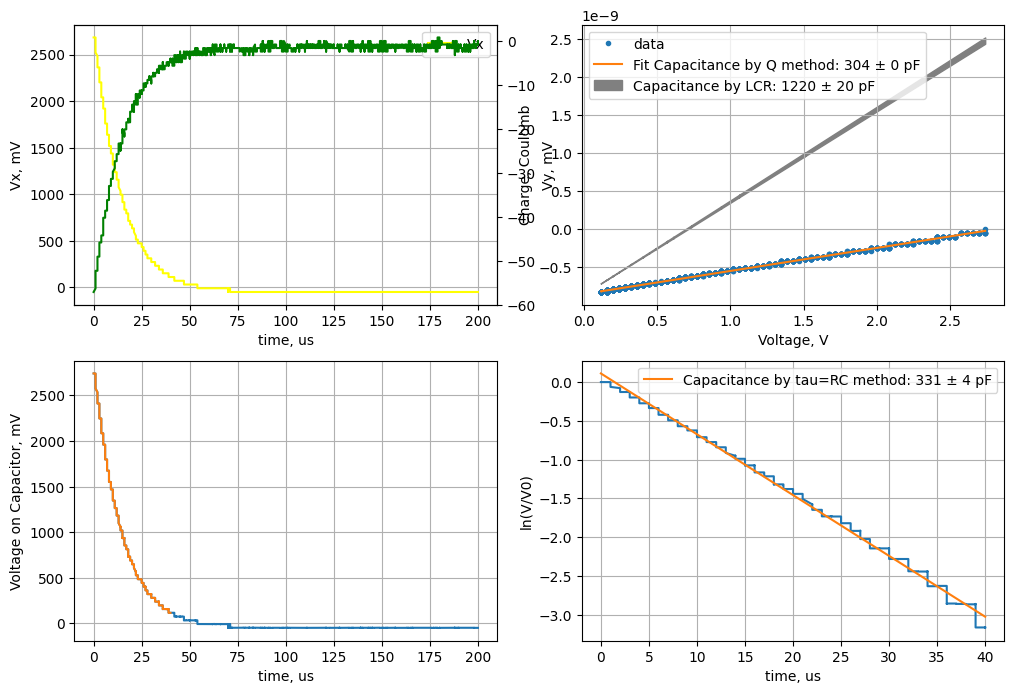

In [11]:


url = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab2_C/2026.03/'

# LCR
C_lcr = 1219e-12
C_lcr_err = C_lcr *0.01 + 3e-12 #±(1.0% rdg +3dgt)

printC(C_lcr, C_lcr_err, 'LCR')

# raw data
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
filename = url+'A260_plastic.csv'
t, vx, vy = np.loadtxt(filename, delimiter=',', skiprows=1, usecols=[0,1,2]).T
t -= np.min(t)
ax = axs[0,0]
ax.plot(t*1e6, vx*1e3, color='yellow', label='Vx')
ax.set_ylabel('Vx, mV')
ax.set_xlabel('time, us')
ax2 = ax.twinx()
ax2.plot(t*1e6, vy*1e3, color='green', label='Vy')
ax2.set_ylabel('Vy, mV')
ax.legend()
ax.grid()

# masked data
V = vx - vy#
I = vy / R2#
ax = axs[1,0]
ax.plot(t * 1e6, V*1e3)
mask =  t*1e6 <  TIME_MAX*1e6
ax.plot(t[mask] * 1e6, V[mask]*1e3)
ax.set_ylabel('Voltage on Capacitor, mV')
ax.set_xlabel('time, us')
ax.grid()

# Q
Q = cumtrapz(I[mask], t[mask], initial=0)
fit = linregress(V[mask], Q)
C = fit.slope
C_err = fit.stderr
text = niceC(C, C_err, 'Q method')
ax = axs[0,1]
ax.plot(V[mask], Q, '.', label='data')
ax.plot(V[mask], fit.intercept + fit.slope * V[mask], label=f'Fit {text}')

lcr_top  = C_lcr + C_lcr_err
lcr_bottom = C_lcr - C_lcr_err
ytop = fit.intercept + lcr_top * V[mask]
ybottom =   fit.intercept + lcr_bottom * V[mask]
ax.fill_between(V[mask], ytop, ybottom, color='gray', label=niceC(C_lcr, C_lcr_err, 'LCR'))

ax.legend()
ax.grid()
ax.set_xlabel('Voltage, V')
ax.set_ylabel('Charge, Coulomb')

# RC
lnv = np.log(V[mask]/V[0])
tmask = t[mask]
ax = axs[1,1]
ax.plot(tmask*1e6, lnv)
fit = linregress(tmask, lnv)
tau = - 1 / fit.slope
tau_rel = np.abs(fit.stderr / fit.slope)
R = R1 + R2
R_rel = sum_err(R1_err/R1,   R2_err/R2)
C_rel = sum_err(tau_rel, R_rel)
C = tau / R
C_err = C * C_rel
text = niceC(C, C_err, 'tau=RC method')
ax.plot(t[mask]*1e6, fit.intercept + fit.slope * t[mask], label=text)
ax.grid()
ax.set_xlabel('time, us')
ax.set_ylabel('ln(V/V0)')
ax.legend()

# geometry
d = 1e-3
# error
d_err = 0.02e-3
d_error_relative =  d_err / d

# Disk surface square
diameter = 260e-3 # mm +- 1mm
diameter_err = 1e-3 #mm
A = np.pi * diameter**2 / 4
A_error_relative  = 2* diameter_err / diameter
C_error_relative = d_error_relative  +  A_error_relative

# Constants
eps0 = scipy.constants.epsilon_0
epsr = 1 # for air between plates

C = A * eps0 * epsr / d
C_err = C * C_error_relative
#printC(C, C_err, 'Geometry')







# Small 180 mm disk, bif pins


Capacitance by LCR: 236 ± 6 pF
Capacitance by Geometry: 220 ± 20 pF


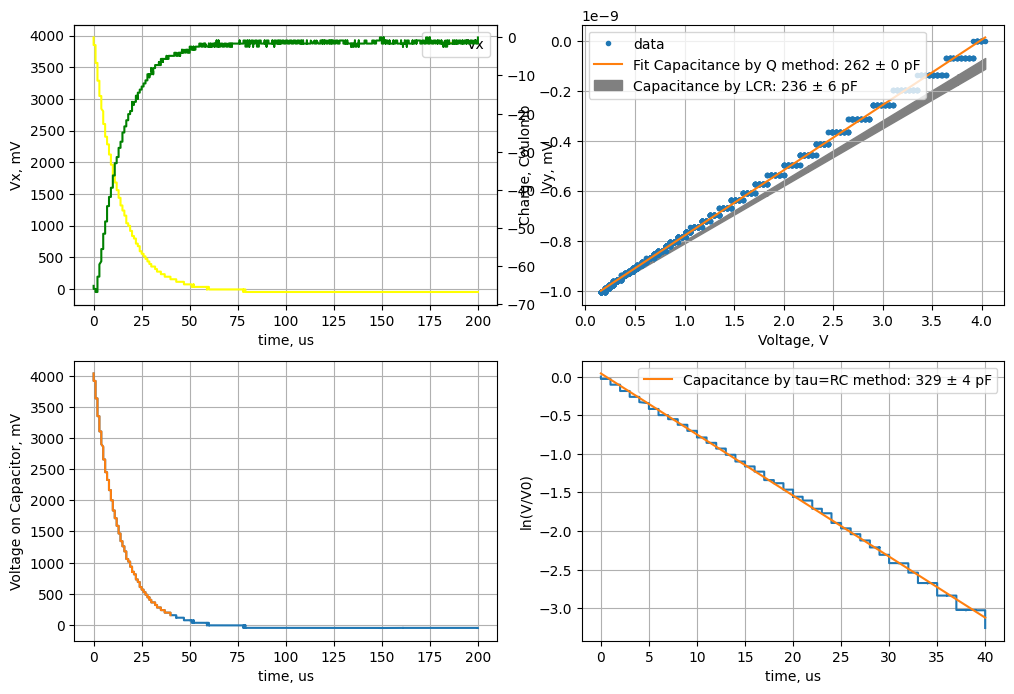

In [12]:
########### small disk
#diam = 180e-3
d = 1e-3 * (1.06 + 1.02 + 1.02) / 3
# LCR = 236
# LCR
C_lcr = 236e-12
C_lcr_err = C_lcr *0.01 + 3e-12 #±(1.0% rdg +3dgt)

printC(C_lcr, C_lcr_err, 'LCR')


# raw data
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
filename = url+'A180_d1_air.csv'
t, vx, vy = np.loadtxt(filename, delimiter=',', skiprows=1, usecols=[0,1,2]).T
t -= np.min(t)
ax = axs[0,0]
ax.plot(t*1e6, vx*1e3, color='yellow', label='Vx')
ax.set_ylabel('Vx, mV')
ax.set_xlabel('time, us')
ax2 = ax.twinx()
ax2.plot(t*1e6, vy*1e3, color='green', label='Vy')
ax2.set_ylabel('Vy, mV')
ax.legend()
ax.grid()

# masked data
V = vx - vy#
I = vy / R2#
ax = axs[1,0]
ax.plot(t * 1e6, V*1e3)
mask =  t*1e6 <  TIME_MAX*1e6
ax.plot(t[mask] * 1e6, V[mask]*1e3)
ax.set_ylabel('Voltage on Capacitor, mV')
ax.set_xlabel('time, us')
ax.grid()

# Q
Q = cumtrapz(I[mask], t[mask], initial=0)
fit = linregress(V[mask], Q)
C = fit.slope
C_err = fit.stderr
text = niceC(C, C_err, 'Q method')
ax = axs[0,1]
ax.plot(V[mask], Q, '.', label='data')
ax.plot(V[mask], fit.intercept + fit.slope * V[mask], label=f'Fit {text}')
lcr_top  = C_lcr + C_lcr_err
lcr_bottom = C_lcr - C_lcr_err
ytop = fit.intercept + lcr_top * V[mask]
ybottom =   fit.intercept + lcr_bottom * V[mask]
ax.fill_between(V[mask], ytop, ybottom, color='gray', label=niceC(C_lcr, C_lcr_err, 'LCR'))
ax.legend()
ax.grid()
ax.set_xlabel('Voltage, V')
ax.set_ylabel('Charge, Coulomb')

# RC
lnv = np.log(V[mask]/V[0])
tmask = t[mask]
ax = axs[1,1]
ax.plot(tmask*1e6, lnv)
fit = linregress(tmask, lnv)
tau = - 1 / fit.slope
tau_rel = np.abs(fit.stderr / fit.slope)
R = R1 + R2
R_rel = sum_err(R1_err/R1,   R2_err/R2)
C_rel = sum_err(tau_rel, R_rel)
C = tau / R
C_err = C * C_rel
text = niceC(C, C_err, 'tau=RC method')
ax.plot(t[mask]*1e6, fit.intercept + fit.slope * t[mask], label=text)
ax.grid()
ax.set_xlabel('time, us')
ax.set_ylabel('ln(V/V0)')
ax.legend()

# geometry
d = 1e-3 * (1.06 + 1.02 + 1.02) / 3
# error
d123_err = 0.02e-3 # mm

d_err = np.sqrt(3) * d123_err
d_error_relative =  d_err / d

# Disk surface square
diameter = 180e-3 # mm +- 1mm
diameter_err = 2e-3 #mm
A = np.pi * diameter**2 / 4
A_error_relative  = 2* diameter_err / diameter
C_error_relative = d_error_relative  +  A_error_relative

# Constants
eps0 = scipy.constants.epsilon_0
epsr = 1 # for air between plates

C = A * eps0 * epsr / d
C_err = C * C_error_relative
printC(C, C_err, 'Geometry')



